# 06 — LIANA: Cell-Cell Communication, Innervated vs. Denervated

**Stage 5 · which signals arrive at TSPC and T-FAP, and how denervation changes them**

Compare ligand-receptor interactions between **innervated (TrkAWT)** and **denervated
(TrkAF592A)** conditions in Cherief 2023.

Key questions:
- Which signals arrive at TSPC in innervated but not denervated tendons? (NGF, PDGF)
- Which signals arrive at T-FAP in denervated but not innervated tendons? (TGFβ, inflammatory)
- What changes in sender → TSPC/T-FAP communication explain the shift toward fibrosis after denervation?

Pipeline: annotate the full dataset (leiden → name, with cluster 8 replaced by the `02`
sub-labels) → run LIANA `rank_aggregate` (mouseconsensus) on each condition separately →
compare scores between conditions → visualise the top differential interactions.

**Inputs**
- `data/Cherief_scRNA-seq/GSE244921_processed.h5ad` — from `01`
- `data/Cherief_scRNA-seq/GSE244921_cluster8_sub.h5ad` — from `02`, supplies the TSPC/T-FAP labels

**Outputs**
- `data/liana/liana_{innervated,denervated}.csv` — full per-condition LIANA results
- `data/liana/liana_differential_all.csv` — `delta_rank` for every LR pair present in both conditions
- `data/liana/liana_differential_stromal_receivers.csv` — the same, filtered to TSPC/T-FAP receivers
- `figures/liana/` — condition UMAP, bubble plots, differential heatmap

**Runs after:** `01`, `02` · **Feeds:** `06b`, `07`

**Environment:** analysis env (`environments/analysis.txt`). Run with the working directory set to `scripts/ipynb/` — every path below is relative to it.

---

**Standing caveat:** this notebook calls `rank_aggregate(..., n_perms=None)`, so
`delta_rank` is a rank-difference heuristic with no significance test behind it.
`06b` reruns the same pipeline with permutation testing enabled; use its p-values
as the primary evidence for any specific LR pair.


## 0. Setup

Imports, paths and output directories.


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

sc.settings.verbosity = 1

ROOT    = Path('../..')
DATA_SC = ROOT / 'data' / 'Cherief_scRNA-seq'
DATA_LI = ROOT / 'data' / 'liana'
FIG     = ROOT / 'figures' / 'liana'
DATA_LI.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# sc.pl.*(save='_x.png') writes to sc.settings.figdir and treats `save` as a
# filename suffix, not a path. Without this line scanpy falls back to its
# default './figures/', which resolves against the notebook's working
# directory and lands in scripts/ipynb/figures/ instead of figures/liana/.
sc.settings.figdir = str(FIG) + '/'

print('liana', li.__version__)

liana 0.1.9


## 1. Annotate full dataset

In [2]:
# Load full 22,615-cell dataset
adata_full = sc.read(DATA_SC / 'GSE244921_processed.h5ad')
print(adata_full)
print(adata_full.obs['leiden'].value_counts().sort_index())

AnnData object with n_obs × n_vars = 22615 × 21761
    obs: 'condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
leiden
0     2834
1      348
2     1418
3     1690
4     3449
5      643
6     2703
7      681
8     3900
9     1417
10    1518
11     505
12     222
13     583


In [3]:
# Cluster → cell type mapping derived from marker expression
# Cluster 8 cells will be replaced with fine-grained TSPC/T-FAP labels below
cluster_map = {
    '0':  'Macrophage',        # Csf1r=1.82, Cd68=1.66, C1qb=1.86
    '1':  'Macrophage',        # Cd68=2.09
    '2':  'Macrophage',        # Csf1r=1.04, C1qb=0.97
    '3':  'Immune_other',      # low all markers — likely lymphocytes
    '4':  'Tenocyte',          # Tnmd=1.52, Scx=1.34, Fmod=1.53, Kera=1.43
    '5':  'Tenocyte',          # Fmod=1.18, Thbs4=1.04, Scx=0.88
    '6':  'Tenocyte',          # Tnmd=0.41, Scx=0.48, Fmod=0.47, Ncam1=0.76
    '7':  'Stromal_other',     # Ncam1=0.93, Tppp3=0.51, Acta2=0.45 — perivascular stromal
    '8':  'PDGFRa_stromal',    # placeholder; replaced with sub-cluster labels below
    '9':  'Smooth_muscle',     # Acta2=1.79, Tagln=1.62
    '10': 'Endothelial',       # Pecam1=3.16, Cdh5=3.12
    '11': 'Immune_other',      # no strong markers
    '12': 'Endothelial',       # Pecam1=2.19, Cdh5=2.18
    '13': 'Macrophage',        # Csf1r=0.69, Cd68=0.58
    '14': 'Immune_other',      # 52 cells only
    '15': 'Stromal_other',     # mixed stromal/macrophage signal
    '16': 'Immune_other',      # no strong markers
}

adata_full.obs['cell_type'] = adata_full.obs['leiden'].map(cluster_map).astype('category')
print(adata_full.obs['cell_type'].value_counts())

cell_type
Tenocyte          6795
Macrophage        5183
PDGFRa_stromal    3900
Immune_other      2568
Endothelial       1740
Smooth_muscle     1417
Stromal_other     1012
Name: count, dtype: int64


In [4]:
# Replace cluster 8 with fine-grained TSPC/T-FAP/Tenogenic-progenitor/Stromal labels
sub = sc.read(DATA_SC / 'GSE244921_cluster8_sub.h5ad')
sub_labels = sub.obs['cell_type']  # TSPC, T-FAP, Tenogenic-progenitor, Stromal

# Map by cell barcode
adata_full.obs['cell_type'] = adata_full.obs['cell_type'].astype(str)
common = adata_full.obs.index.intersection(sub_labels.index)
adata_full.obs.loc[common, 'cell_type'] = sub_labels.loc[common].astype(str)
adata_full.obs['cell_type'] = adata_full.obs['cell_type'].astype('category')

print('Final cell type distribution:')
print(adata_full.obs['cell_type'].value_counts())

Final cell type distribution:
cell_type
Tenocyte                6795
Macrophage              5183
Immune_other            2568
Endothelial             1740
Smooth_muscle           1417
Stromal                 1388
T-FAP                   1245
Stromal_other           1012
Tenogenic-progenitor     816
TSPC                     451
Name: count, dtype: int64


In [5]:
# Drop small / uninterpretable groups for cleaner LIANA output
# Keep: Macrophage, Tenocyte, TSPC, T-FAP, Tenogenic-progenitor, Stromal, Endothelial, Smooth_muscle, Stromal_other
keep = {
    'Macrophage', 'Tenocyte', 'TSPC', 'T-FAP', 'Tenogenic-progenitor',
    'Stromal', 'Endothelial', 'Smooth_muscle', 'Stromal_other'
}
mask = adata_full.obs['cell_type'].isin(keep)
adata = adata_full[mask].copy()
print(f'Retained {adata.n_obs} / {adata_full.n_obs} cells')
print(adata.obs['cell_type'].value_counts())

Retained 20047 / 22615 cells
cell_type
Tenocyte                6795
Macrophage              5183
Endothelial             1740
Smooth_muscle           1417
Stromal                 1388
T-FAP                   1245
Stromal_other           1012
Tenogenic-progenitor     816
TSPC                     451
Name: count, dtype: int64


C:\Users\fangy\AppData\Local\Temp\ipykernel_8104\2806160447.py:13: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


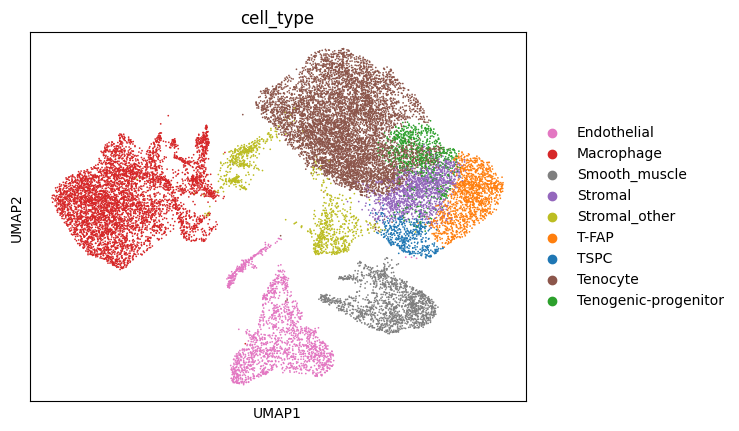

In [6]:
# UMAP sanity check
palette = {
    'TSPC':                 '#1f77b4',
    'T-FAP':                '#ff7f0e',
    'Tenogenic-progenitor': '#2ca02c',
    'Stromal':              '#9467bd',
    'Macrophage':           '#d62728',
    'Tenocyte':             '#8c564b',
    'Endothelial':          '#e377c2',
    'Smooth_muscle':        '#7f7f7f',
    'Stromal_other':        '#bcbd22',
}
sc.pl.umap(adata, color='cell_type', palette=palette, save='_liana_celltypes.png')

## 2. Run LIANA per condition

Run `rank_aggregate` (aggregates CellChat, CellPhoneDB, Connectome, iTALK, NicheNet scores) on innervated and denervated subsets separately using the mouse consensus LR database.

In [7]:
# Compatibility patches for liana 0.1.9 on scipy >= 1.14 + NumPy >= 2.0
import scipy.sparse as sp
import liana.method._liana_pipe as _lp
import liana.method.sc._cellchat as _cc

# 1. scipy: .A removed from csr_array → use .toarray()
def _trimean_patched(a, axis=0):
    arr = a.toarray() if sp.issparse(a) else np.asarray(a)
    return np.mean(np.quantile(arr, q=[0.25, 0.5, 0.5, 0.75], axis=axis), axis=axis)

_lp._trimean = _trimean_patched

# 2. NumPy 2.0: np.product removed → np.prod
def _lr_probability_patched(perm_stats, axis=0):
    lr_prob = np.prod(perm_stats, axis=axis)
    return lr_prob / (0.5 + lr_prob)

_cc._lr_probability = _lr_probability_patched

print('liana patches applied (scipy .A → .toarray(), np.product → np.prod)')

liana patches applied (scipy .A → .toarray(), np.product → np.prod)


In [8]:
conditions = {'innervated': 'TrkAWT', 'denervated': 'TrkAF592A'}
liana_results = {}

for label, cond_val in conditions.items():
    print(f'\n=== Running LIANA: {label} ({cond_val}) ===')
    sub = adata[adata.obs['condition'] == cond_val].copy()
    print(f'  {sub.n_obs} cells')
    print(sub.obs['cell_type'].value_counts().to_string())

    li.mt.rank_aggregate(
        sub,
        groupby='cell_type',
        resource_name='mouseconsensus',
        expr_prop=0.1,      # ligand/receptor must be expressed in ≥10% of sender/receiver
        min_cells=10,
        use_raw=True,
        n_perms=None,       # skip permutation; use aggregate score rank only
        verbose=True,
        inplace=True,
    )
    liana_results[label] = sub.uns['liana_res'].copy()
    print(f'  → {len(liana_results[label])} LR pairs scored')


=== Running LIANA: innervated (TrkAWT) ===
  11478 cells
cell_type
Tenocyte                4018
Macrophage              3077
Endothelial              859
Stromal                  828
Stromal_other            718
Smooth_muscle            712
T-FAP                    551
Tenogenic-progenitor     385
TSPC                     330
Using `.raw`!
263 features of mat are empty, they will be removed.


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\legacy_api_wrap\__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\indexing.py:1858: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_pipe_utils\_pre.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


0.11 of entities in the resource are missing from the data.
Generating ligand-receptor stats for 11478 samples and 21498 features


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_liana_pipe.py:312: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_liana_pipe.py:317: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_liana_pipe.py:320: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
Running CellChat
  → 56701 LR pairs scored

=== Running LIANA: denervated (TrkAF592A) ===
  8569 cells
cell_type
Tenocyte                2777
Macrophage              2106
Endothelial              881
Smooth_muscle            705
T-FAP                    694
Stromal                  560
Tenogenic-progenitor     431
Stromal_other            294
TSPC                     121
Using `.raw`!
333 features of mat are empty, they will be removed.


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\legacy_api_wrap\__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\indexing.py:1858: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_pipe_utils\_pre.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


0.12 of entities in the resource are missing from the data.
Generating ligand-receptor stats for 8569 samples and 21428 features
Assuming that counts were `natural` log-normalized!


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_liana_pipe.py:312: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_liana_pipe.py:317: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\liana\method\_liana_pipe.py:320: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
Running CellChat
  → 57233 LR pairs scored


In [9]:
# Quick look at top interactions in each condition
RANK_COL = 'magnitude_rank'  # liana 0.1.9 output column (lower = stronger interaction)

for label, res in liana_results.items():
    print(f'\n=== Top 15 interactions — {label} ===')
    top = res.sort_values(RANK_COL).head(15)
    print(top[['source', 'target', 'ligand_complex', 'receptor_complex', RANK_COL]].to_string(index=False))


=== Top 15 interactions — innervated ===
              source     target ligand_complex receptor_complex  magnitude_rank
            Tenocyte       TSPC         Col1a1             Cd44    2.082538e-13
Tenogenic-progenitor       TSPC         Col1a1             Cd44    1.666001e-12
            Tenocyte       TSPC         Col1a2             Cd44    5.622655e-12
Tenogenic-progenitor       TSPC         Col1a2             Cd44    1.332754e-11
               T-FAP       TSPC         Col1a1             Cd44    2.602989e-11
               T-FAP       TSPC         Col1a2             Cd44    4.497886e-11
             Stromal       TSPC         Col1a1             Cd44    7.142351e-11
       Stromal_other       TSPC         Col1a1             Cd44    1.516431e-10
             Stromal       TSPC         Col1a2             Cd44    1.517956e-10
                TSPC       TSPC         Col1a1             Cd44    4.311188e-10
            Tenocyte Macrophage         Col1a1             Cd44    4.574368e-1

## 3. Differential analysis: innervated vs. denervated

For each (source, target, ligand, receptor) pair present in both conditions, compute:

`delta_rank = rank_denervated − rank_innervated`

- **delta_rank < 0** → interaction is *stronger* (lower rank = higher score) in denervated
- **delta_rank > 0** → interaction is *stronger* in innervated

In [10]:
key_cols = ['source', 'target', 'ligand_complex', 'receptor_complex']

inn = liana_results['innervated'][key_cols + [RANK_COL]].rename(columns={RANK_COL: 'rank_innervated'})
den = liana_results['denervated'][key_cols + [RANK_COL]].rename(columns={RANK_COL: 'rank_denervated'})

diff = inn.merge(den, on=key_cols, how='inner')
diff['delta_rank'] = diff['rank_denervated'] - diff['rank_innervated']

print(f'LR pairs present in both conditions: {len(diff)}')
print(diff.describe()[['rank_innervated', 'rank_denervated', 'delta_rank']].round(3))

LR pairs present in both conditions: 52646
       rank_innervated  rank_denervated  delta_rank
count        52646.000        52646.000   52646.000
mean             0.673            0.671      -0.002
std              0.363            0.362       0.168
min              0.000            0.000      -0.955
25%              0.381            0.383      -0.017
50%              0.808            0.795       0.000
75%              1.000            1.000       0.008
max              1.000            1.000       0.943


In [11]:
# Focus on TSPC and T-FAP as receiver cells
stromal_receivers = ['TSPC', 'T-FAP']
diff_stromal = diff[diff['target'].isin(stromal_receivers)].copy()
print(f'LR pairs with TSPC or T-FAP as receiver: {len(diff_stromal)}')

# Top interactions GAINED in innervated (delta_rank > 0 = weaker in denervated = gained in innervated)
print('\n=== Top interactions STRONGER in INNERVATED (delta_rank > 0) ===')
inn_gained = diff_stromal.sort_values('delta_rank', ascending=False).head(20)
print(inn_gained[key_cols + ['rank_innervated', 'rank_denervated', 'delta_rank']].to_string(index=False))

print('\n=== Top interactions STRONGER in DENERVATED (delta_rank < 0) ===')
den_gained = diff_stromal.sort_values('delta_rank', ascending=True).head(20)
print(den_gained[key_cols + ['rank_innervated', 'rank_denervated', 'delta_rank']].to_string(index=False))

LR pairs with TSPC or T-FAP as receiver: 11669

=== Top interactions STRONGER in INNERVATED (delta_rank > 0) ===
              source target ligand_complex receptor_complex  rank_innervated  rank_denervated  delta_rank
       Stromal_other  T-FAP          Efna1            Epha3         0.063672         1.000000    0.936328
                TSPC  T-FAP         Sema3d      Nrp2_Plxna2         0.120930         1.000000    0.879070
                TSPC  T-FAP         Sema3d      Nrp1_Plxna2         0.120930         1.000000    0.879070
       Stromal_other  T-FAP         Sema4a           Plxnd1         0.144454         1.000000    0.855546
               T-FAP  T-FAP         Sema3d      Nrp1_Plxna2         0.195938         1.000000    0.804062
               T-FAP  T-FAP         Sema3d      Nrp2_Plxna2         0.195938         1.000000    0.804062
                TSPC   TSPC           Bmp3           Bmpr1b         0.210185         1.000000    0.789815
             Stromal  T-FAP         Sem

In [12]:
# Highlight key signalling axes of interest
pathways = {
    'NGF/Neurotrophin': ['Ngf', 'Ntf3', 'Ntf4', 'Bdnf'],
    'TGFb':             ['Tgfb1', 'Tgfb2', 'Tgfb3'],
    'PDGF':             ['Pdgfa', 'Pdgfb', 'Pdgfc', 'Pdgfd'],
    'Wnt':              ['Wnt2', 'Wnt4', 'Wnt5a', 'Wnt5b', 'Wnt11'],
    'FGF':              ['Fgf2', 'Fgf7', 'Fgf10'],
    'VEGF':             ['Vegfa', 'Vegfb', 'Vegfc'],
    'IL6_JAK':          ['Il6', 'Il6st', 'Lif'],
    'Collagen_ECM':     ['Col1a1', 'Col3a1', 'Fn1', 'Postn'],
}

print('\n=== Pathway-specific interactions at TSPC/T-FAP ===')
for pathway, ligands in pathways.items():
    subset = diff_stromal[
        diff_stromal['ligand_complex'].str.split('_').apply(lambda x: any(l in x for l in ligands))
    ].sort_values('delta_rank', ascending=False)
    if len(subset) > 0:
        print(f'\n  {pathway} (n={len(subset)}):')
        print(subset[key_cols + ['delta_rank']].head(8).to_string(index=False))


=== Pathway-specific interactions at TSPC/T-FAP ===

  NGF/Neurotrophin (n=26):
              source target ligand_complex receptor_complex  delta_rank
               T-FAP   TSPC           Bdnf            Erbb2    0.426700
Tenogenic-progenitor   TSPC           Bdnf            Erbb2    0.383607
       Stromal_other   TSPC           Bdnf            Erbb2    0.294886
                TSPC   TSPC            Ngf            Erbb2    0.284477
            Tenocyte   TSPC           Bdnf            Erbb2    0.261668
       Smooth_muscle   TSPC           Bdnf            Erbb2    0.259247
       Smooth_muscle  T-FAP            Ngf        Kidins220    0.231420
       Smooth_muscle   TSPC            Ngf           Maged1    0.224815

  TGFb (n=500):
              source target ligand_complex receptor_complex  delta_rank
         Endothelial  T-FAP          Tgfb1            Itgb3    0.655347
       Stromal_other  T-FAP          Tgfb1            Itgb3    0.611874
            Tenocyte  T-FAP          T

## 4. Visualise

Saved: ..\..\figures\liana\dotplot_innervated_stromal.png


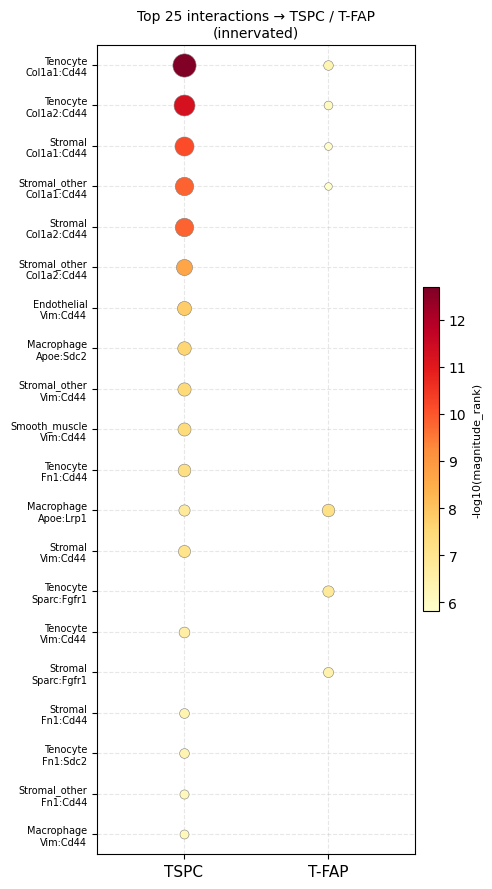

In [13]:
def bubble_plot(res, condition_label, top_n=20, save_path=None):
    """
    Bubble plot of top LR interactions arriving at TSPC or T-FAP.
    Rows = interactions  |  cols = TSPC / T-FAP
    Bubble size & colour = -log10(magnitude_rank)
    """
    senders_use = list(keep - {'TSPC', 'T-FAP', 'Tenogenic-progenitor'})
    df = (
        res
        .loc[lambda d: d['target'].isin(['TSPC', 'T-FAP']) & d['source'].isin(senders_use)]
        .sort_values(RANK_COL)
        .head(top_n)
        .copy()
    )
    df['label']     = df['source'] + '\n' + df['ligand_complex'] + ':' + df['receptor_complex']
    df['neg_log10'] = -np.log10(df[RANK_COL].clip(lower=1e-300))

    targets  = ['TSPC', 'T-FAP']
    interactions = df['label'].unique()
    x_pos = {t: i for i, t in enumerate(targets)}
    y_pos = {lbl: i for i, lbl in enumerate(reversed(interactions))}

    fig, ax = plt.subplots(figsize=(5, max(6, len(interactions) * 0.45)))
    vmin, vmax = df['neg_log10'].min(), df['neg_log10'].max()
    cmap = plt.cm.YlOrRd

    for _, row in df.iterrows():
        x = x_pos[row['target']]
        y = y_pos[row['label']]
        v = row['neg_log10']
        size = 30 + 250 * (v - vmin) / max(vmax - vmin, 1)
        color = cmap((v - vmin) / max(vmax - vmin, 1))
        ax.scatter(x, y, s=size, c=[color], edgecolors='grey', linewidths=0.4, zorder=3)

    ax.set_xticks(range(len(targets)))
    ax.set_xticklabels(targets, fontsize=11)
    ax.set_yticks(range(len(interactions)))
    ax.set_yticklabels([list(reversed(interactions))[i] for i in range(len(interactions))], fontsize=7)
    ax.set_xlim(-0.6, len(targets) - 0.4)
    ax.set_ylim(-0.5, len(interactions) - 0.5)
    ax.grid(True, axis='both', linestyle='--', alpha=0.3)
    ax.set_title(f'Top {top_n} interactions → TSPC / T-FAP\n({condition_label})', fontsize=10)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
    cbar.set_label('-log10(magnitude_rank)', fontsize=8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

senders = list(keep - {'TSPC', 'T-FAP', 'Tenogenic-progenitor'})
bubble_plot(liana_results['innervated'], 'innervated', top_n=25,
            save_path=FIG / 'dotplot_innervated_stromal.png')

Saved: ..\..\figures\liana\dotplot_denervated_stromal.png


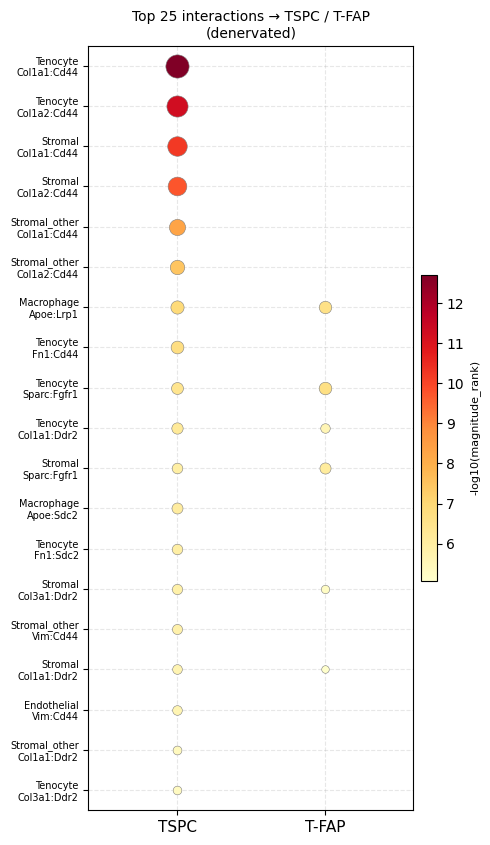

In [14]:
bubble_plot(liana_results['denervated'], 'denervated', top_n=25,
            save_path=FIG / 'dotplot_denervated_stromal.png')

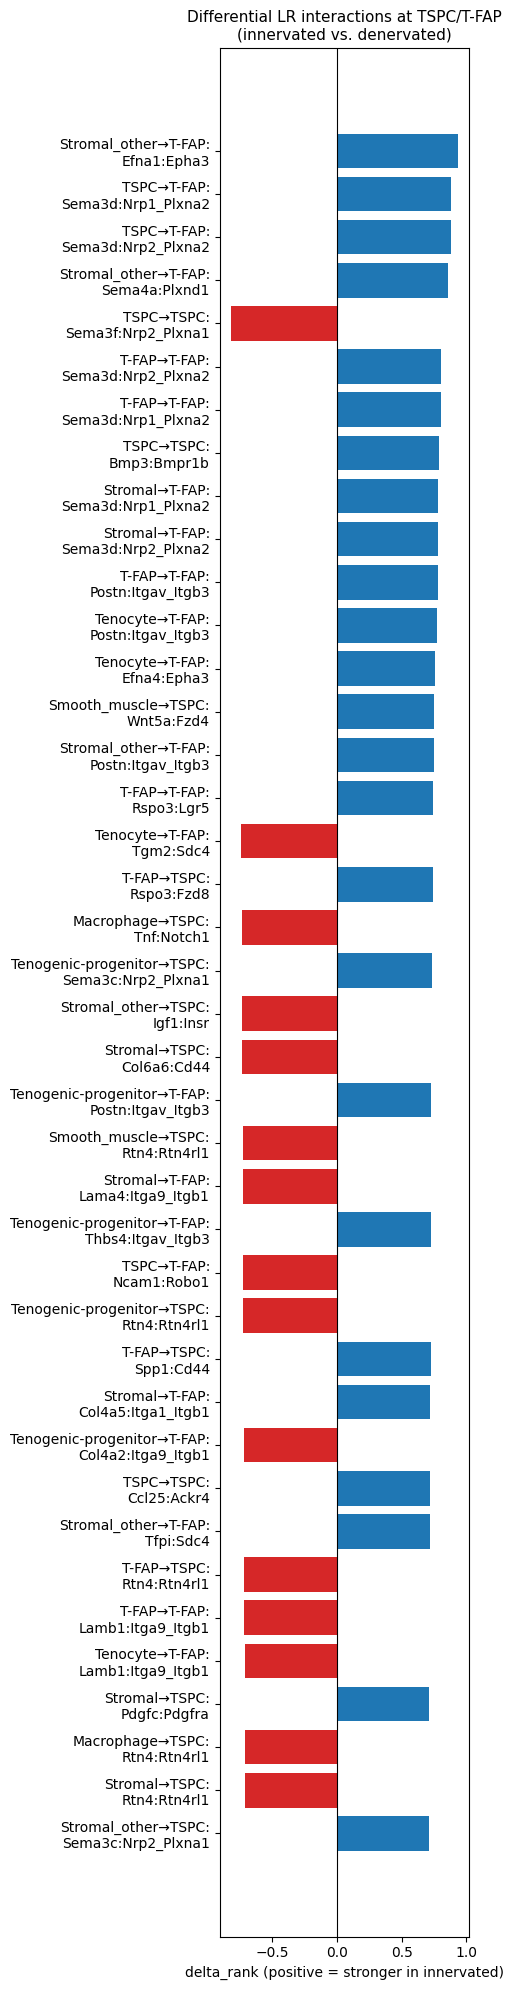

In [15]:
# Heatmap: delta_rank for top differential interactions at TSPC and T-FAP
# Positive = stronger in innervated; negative = stronger in denervated
top_diff = (
    diff_stromal
    .assign(abs_delta=diff_stromal['delta_rank'].abs())
    .sort_values('abs_delta', ascending=False)
    .head(40)
    .copy()
)
top_diff['interaction'] = (
    top_diff['source'] + '→' + top_diff['target'] + ':\n'
    + top_diff['ligand_complex'] + ':' + top_diff['receptor_complex']
)

fig, ax = plt.subplots(figsize=(5, 20))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in top_diff['delta_rank']]
bars = ax.barh(top_diff['interaction'], top_diff['delta_rank'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('delta_rank (positive = stronger in innervated)')
ax.set_title('Differential LR interactions at TSPC/T-FAP\n(innervated vs. denervated)', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG / 'barplot_differential_stromal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Export

In [16]:
# Save per-condition LIANA results
for label, res in liana_results.items():
    out = DATA_LI / f'liana_{label}.csv'
    res.to_csv(out, index=False)
    print(f'Saved: {out}')

# Save differential table (all receivers)
diff.to_csv(DATA_LI / 'liana_differential_all.csv', index=False)
print(f'Saved: {DATA_LI}/liana_differential_all.csv')

# Save TSPC/T-FAP focused differential table
diff_stromal.sort_values('delta_rank', ascending=False).to_csv(
    DATA_LI / 'liana_differential_stromal_receivers.csv', index=False
)
print(f'Saved: {DATA_LI}/liana_differential_stromal_receivers.csv')

Saved: ..\..\data\liana\liana_innervated.csv
Saved: ..\..\data\liana\liana_denervated.csv
Saved: ..\..\data\liana/liana_differential_all.csv
Saved: ..\..\data\liana/liana_differential_stromal_receivers.csv
